# Inference — High Neutrino Purity Data

| TTree | Entries | Contenido |
|-------|---------|----------|
| `opanatree/inference_tree` | 614 | Predicciones CNN (eventos que pasaron filtros) |
| `nusliceana/nuslicetree` | 5000 | Info Pandora slice + predicciones CNN (todos los eventos) |

Importa librerías, carga el estilo de figuras compartido (`plot_style.py`), define el path al archivo ROOT, las constantes del volumen fiducial y la función gaussiana usada en los ajustes.

In [3]:
import sys
import os
from datetime import datetime
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import curve_fit

sys.path.insert(0, '/exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/NuIntNNOpReco/2-cnn-training-notebooks/')
from plot_style import *

ROOT_FILE = '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_DATA/High_neutrino_purity/v_grid/merged_grid_v2404_nuslice_resnet.root'
PLACEHOLDER = -900
FV_X = (-180.0, 180.0)
FV_Y = (-185.0, 185.0)
FV_Z = (  10.0, 490.0)

_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
FIG_DIR = f"/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_DATA/High_neutrino_purity/figures_{_ts}"
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Figures will be saved to: {FIG_DIR}")

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)

Figures will be saved to: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_DATA/High_neutrino_purity/figures_20260427_142054


## 1. Cargar TTrees

Abre el archivo ROOT con `uproot` y carga los dos TTrees: `inference_tree` (predicciones CNN, eventos que pasaron todos los filtros) y `nuslicetree` (info de slices Pandora para todos los eventos).

In [6]:
f = uproot.open(ROOT_FILE)

df_inf      = f['ResNetInference/inference_tree'].arrays(library='pd')
df_slice  = f['nusliceana/nuslicetree'].arrays(library='pd')

print(f'inference_tree : {len(df_inf):>5} eventos')
print(f'nuslicetree    : {len(df_slice):>5} eventos')
display(df_inf.head(3))
display(df_slice.head(3))

inference_tree : 30606 eventos
nuslicetree    : 242023 eventos


,run,subrun,event,passed_filters,pred_x,pred_y,pred_z,selected_tpc,pred_dir_y,pred_dir_z
0,18253,1,483861,True,149.219596,-28.816330,333.830804,1,0.288096,0.957601
1,18253,1,485929,True,154.900777,-144.826567,246.181309,1,-0.367521,0.930015
2,18253,1,486237,True,116.447675,-34.247750,59.160374,1,-0.356885,0.934148


,run,subrun,event,sliceID,sliceNuScore,vtxX,vtxY,vtxZ,spBaryX,spBaryY,...,spPCAv2x,spPCAv2y,spPCAv2z,spPCAv3x,spPCAv3y,spPCAv3z,nSpacePoints,cnnPredX,cnnPredY,cnnPredZ
0,18253,1,483289,-1,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,0,-999.0,-999.0,-999.0
1,18253,1,483619,-1,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,0,-999.0,-999.0,-999.0
2,18253,1,483641,-1,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,0,-999.0,-999.0,-999.0


## 2. Cutflow — eficiencia de cada filtro

El `NuSliceAnalyzer` almacena **−999** cuando el evento no pasa la selección neutrino.  
Los cortes is_clear_cosmic, NuScore < 0.6 y FV no son separables en este ROOT file: todos producen −999.

Cuenta cuántos eventos pasan cada etapa de selección (total → selección ν → CNN válido) y genera dos figuras: cutflow acumulado y rechazo por etapa.

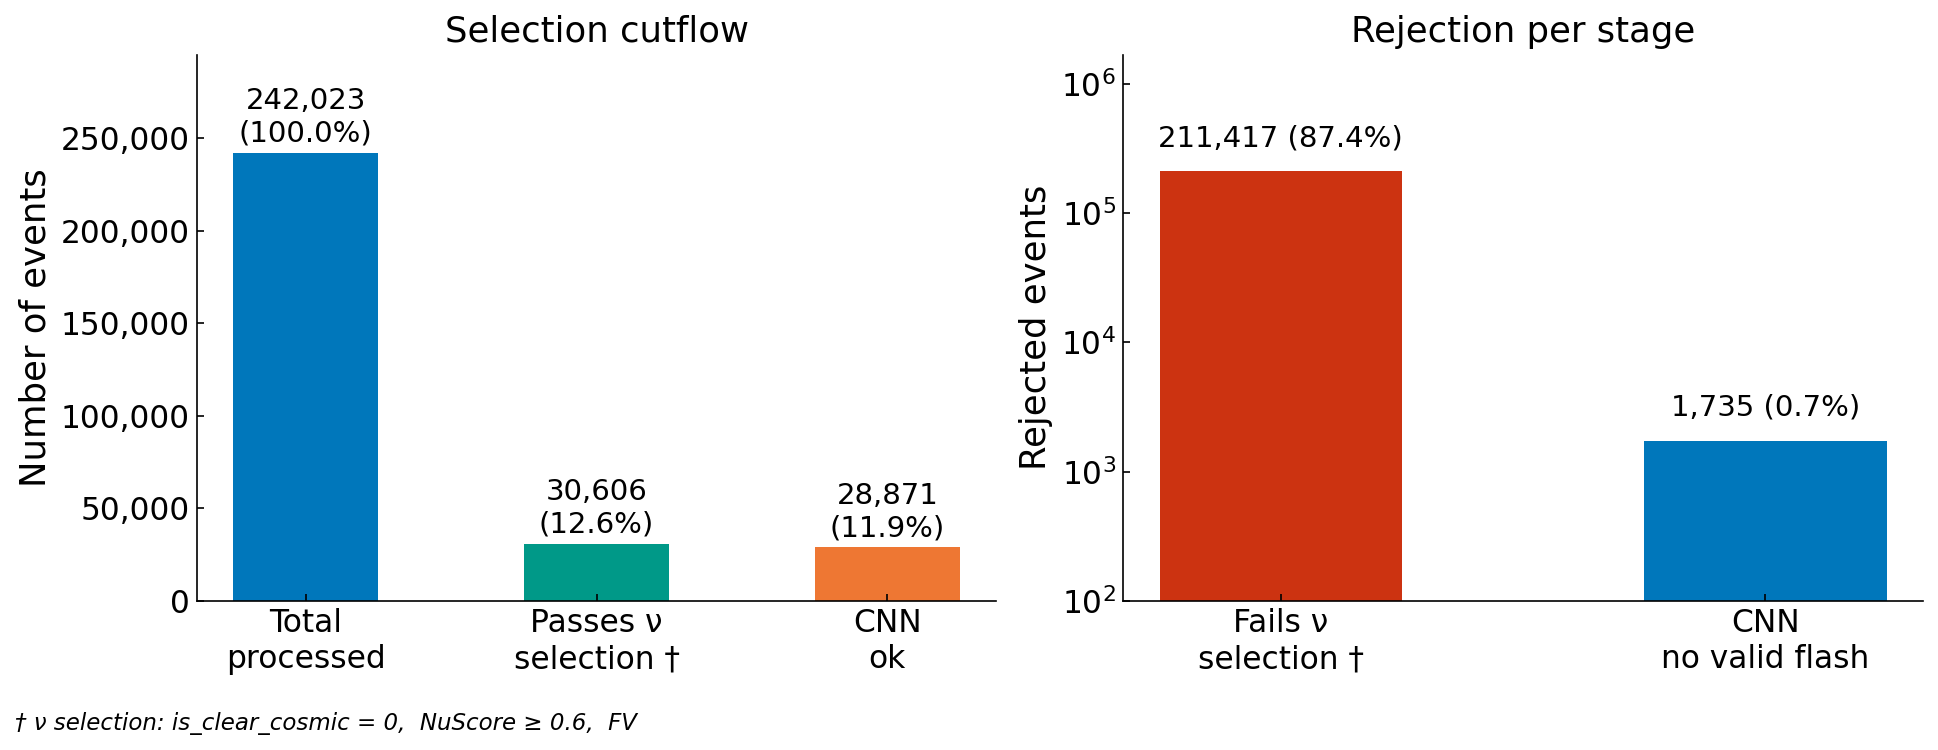

Total efficiency: 28,871 / 242,023 = 11.9%


In [7]:
_fl = 17; _ft = 15; _fs = 14

n_total  = len(df_slice)
n_selec  = (df_slice['sliceNuScore'] > PLACEHOLDER).sum()
n_CNN = (df_inf['pred_x'] > PLACEHOLDER).sum()

labels      = ['Total\nprocessed', 'Passes \u03bd\nselection \u2020', 'CNN\nok']
counts      = [n_total, n_selec, n_CNN]
colors_bar  = [C_PRIMARY, C_TERTIARY, C_SECONDARY]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: cumulative cutflow ───────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(labels, counts, color=colors_bar, edgecolor='none', width=0.5)
for bar, n in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + n_total * 0.012,
            f'{n:,}\n({n / n_total * 100:.1f}%)',
            ha='center', va='bottom', fontsize=_fs)
ax.set_ylabel('Number of events', fontsize=_fl)
ax.set_title('Selection cutflow', fontsize=_fl, fontweight='normal')
ax.set_ylim(0, n_total * 1.22)
ax.tick_params(axis='x', labelsize=_ft)
ax.tick_params(axis='y', labelsize=_ft)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.minorticks_off()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)

# ── Right: rejection per stage (log scale) ────────────────────────────────────
ax = axes[1]
rej_labels  = ['Fails \u03bd\nselection \u2020', 'CNN\nno valid flash']
rej_counts  = [n_total - n_selec, n_selec - n_CNN]
rej_colors  = [C_ALERT, C_PRIMARY]
bars2 = ax.bar(rej_labels, rej_counts, color=rej_colors, edgecolor='none', width=0.5)
for bar, n in zip(bars2, rej_counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.4,
            f'{n:,} ({n / n_total * 100:.1f}%)',
            ha='center', va='bottom', fontsize=_fs)
ax.set_ylabel('Rejected events', fontsize=_fl)
ax.set_title('Rejection per stage', fontsize=_fl, fontweight='normal')
ax.set_yscale('log')
ax.set_ylim(1e2, max(rej_counts) * 8)
ax.tick_params(axis='x', labelsize=_ft)
ax.tick_params(axis='y', labelsize=_ft)
ax.minorticks_off()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)

footnote = '\u2020 \u03bd selection: is_clear_cosmic = 0,  NuScore \u2265 0.6,  FV'
plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.01, 0.01, footnote, fontsize=11, style='italic', va='bottom')

fig.savefig(os.path.join(FIG_DIR, 'cutflow.png'), dpi=SAVE_DPI, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'cutflow.pdf'), bbox_inches='tight')
plt.show()

print(f'Total efficiency: {n_CNN:,} / {n_total:,} = {n_CNN/n_total*100:.1f}%')

## 3. Merge CNN + Pandora/CNN

**Nota X:** CNN no distingue TPC → predice siempre |X|.  
El residuo en X se calcula como `|pred_x| − |vtxX|`.

Combina `inference_tree` y `nuslicetree` por `(run, subrun, event)`, descarta predicciones placeholder y calcula los residuos CNN − Pandora en X (agnostico de TPC → valores absolutos), Y, Z y 3D.

In [9]:
df = pd.merge(
    df_inf[['run','subrun','event','pred_x','pred_y','pred_z',
            'pred_dir_y','pred_dir_z','selected_tpc']],
    df_slice,
    on=['run','subrun','event'],
    how='inner'
)

# Exclude CNN placeholders (pred_x == −999)
df = df[df['pred_x'] > PLACEHOLDER].copy()
print(f'Events after merge (valid CNN): {len(df)}')

# Residuals CNN vs Pandora vertex (X: TPC-agnostic → absolute values)
df['res_x']  = np.abs(df['pred_x']) - np.abs(df['vtxX'])
df['res_y']  = df['pred_y'] - df['vtxY']
df['res_z']  = df['pred_z'] - df['vtxZ']
df['res_3d'] = np.sqrt(df['res_x']**2 + df['res_y']**2 + df['res_z']**2)

display(df[['pred_x','vtxX','res_x','pred_y','vtxY','res_y','pred_z','vtxZ','res_z','res_3d']].head(4))

Events after merge (valid CNN): 28871


,pred_x,vtxX,res_x,pred_y,vtxY,res_y,pred_z,vtxZ,res_z,res_3d
0,149.219596,118.255333,30.964263,-28.816330,-74.676155,45.859825,333.830804,214.559647,119.271157,131.482006
1,154.900777,162.201447,-7.300669,-144.826567,-100.199066,-44.627501,246.181309,125.676483,120.504826,128.710243
2,116.447675,53.761318,62.686357,-34.247750,8.110330,-42.358080,59.160374,21.420462,37.739912,84.546362
3,183.386290,82.902466,100.483824,-73.213005,-125.227272,52.014267,393.553436,263.200012,130.353424,172.610828


## 4. CNN vs Pandora vertex

Fila superior: scatter CNN pred vs vértice Pandora en las tres coordenadas con línea ideal (diagonal). Fila inferior: histogramas de residuos con ajuste gaussiano; la caja de estadísticos muestra μ y σ del ajuste.

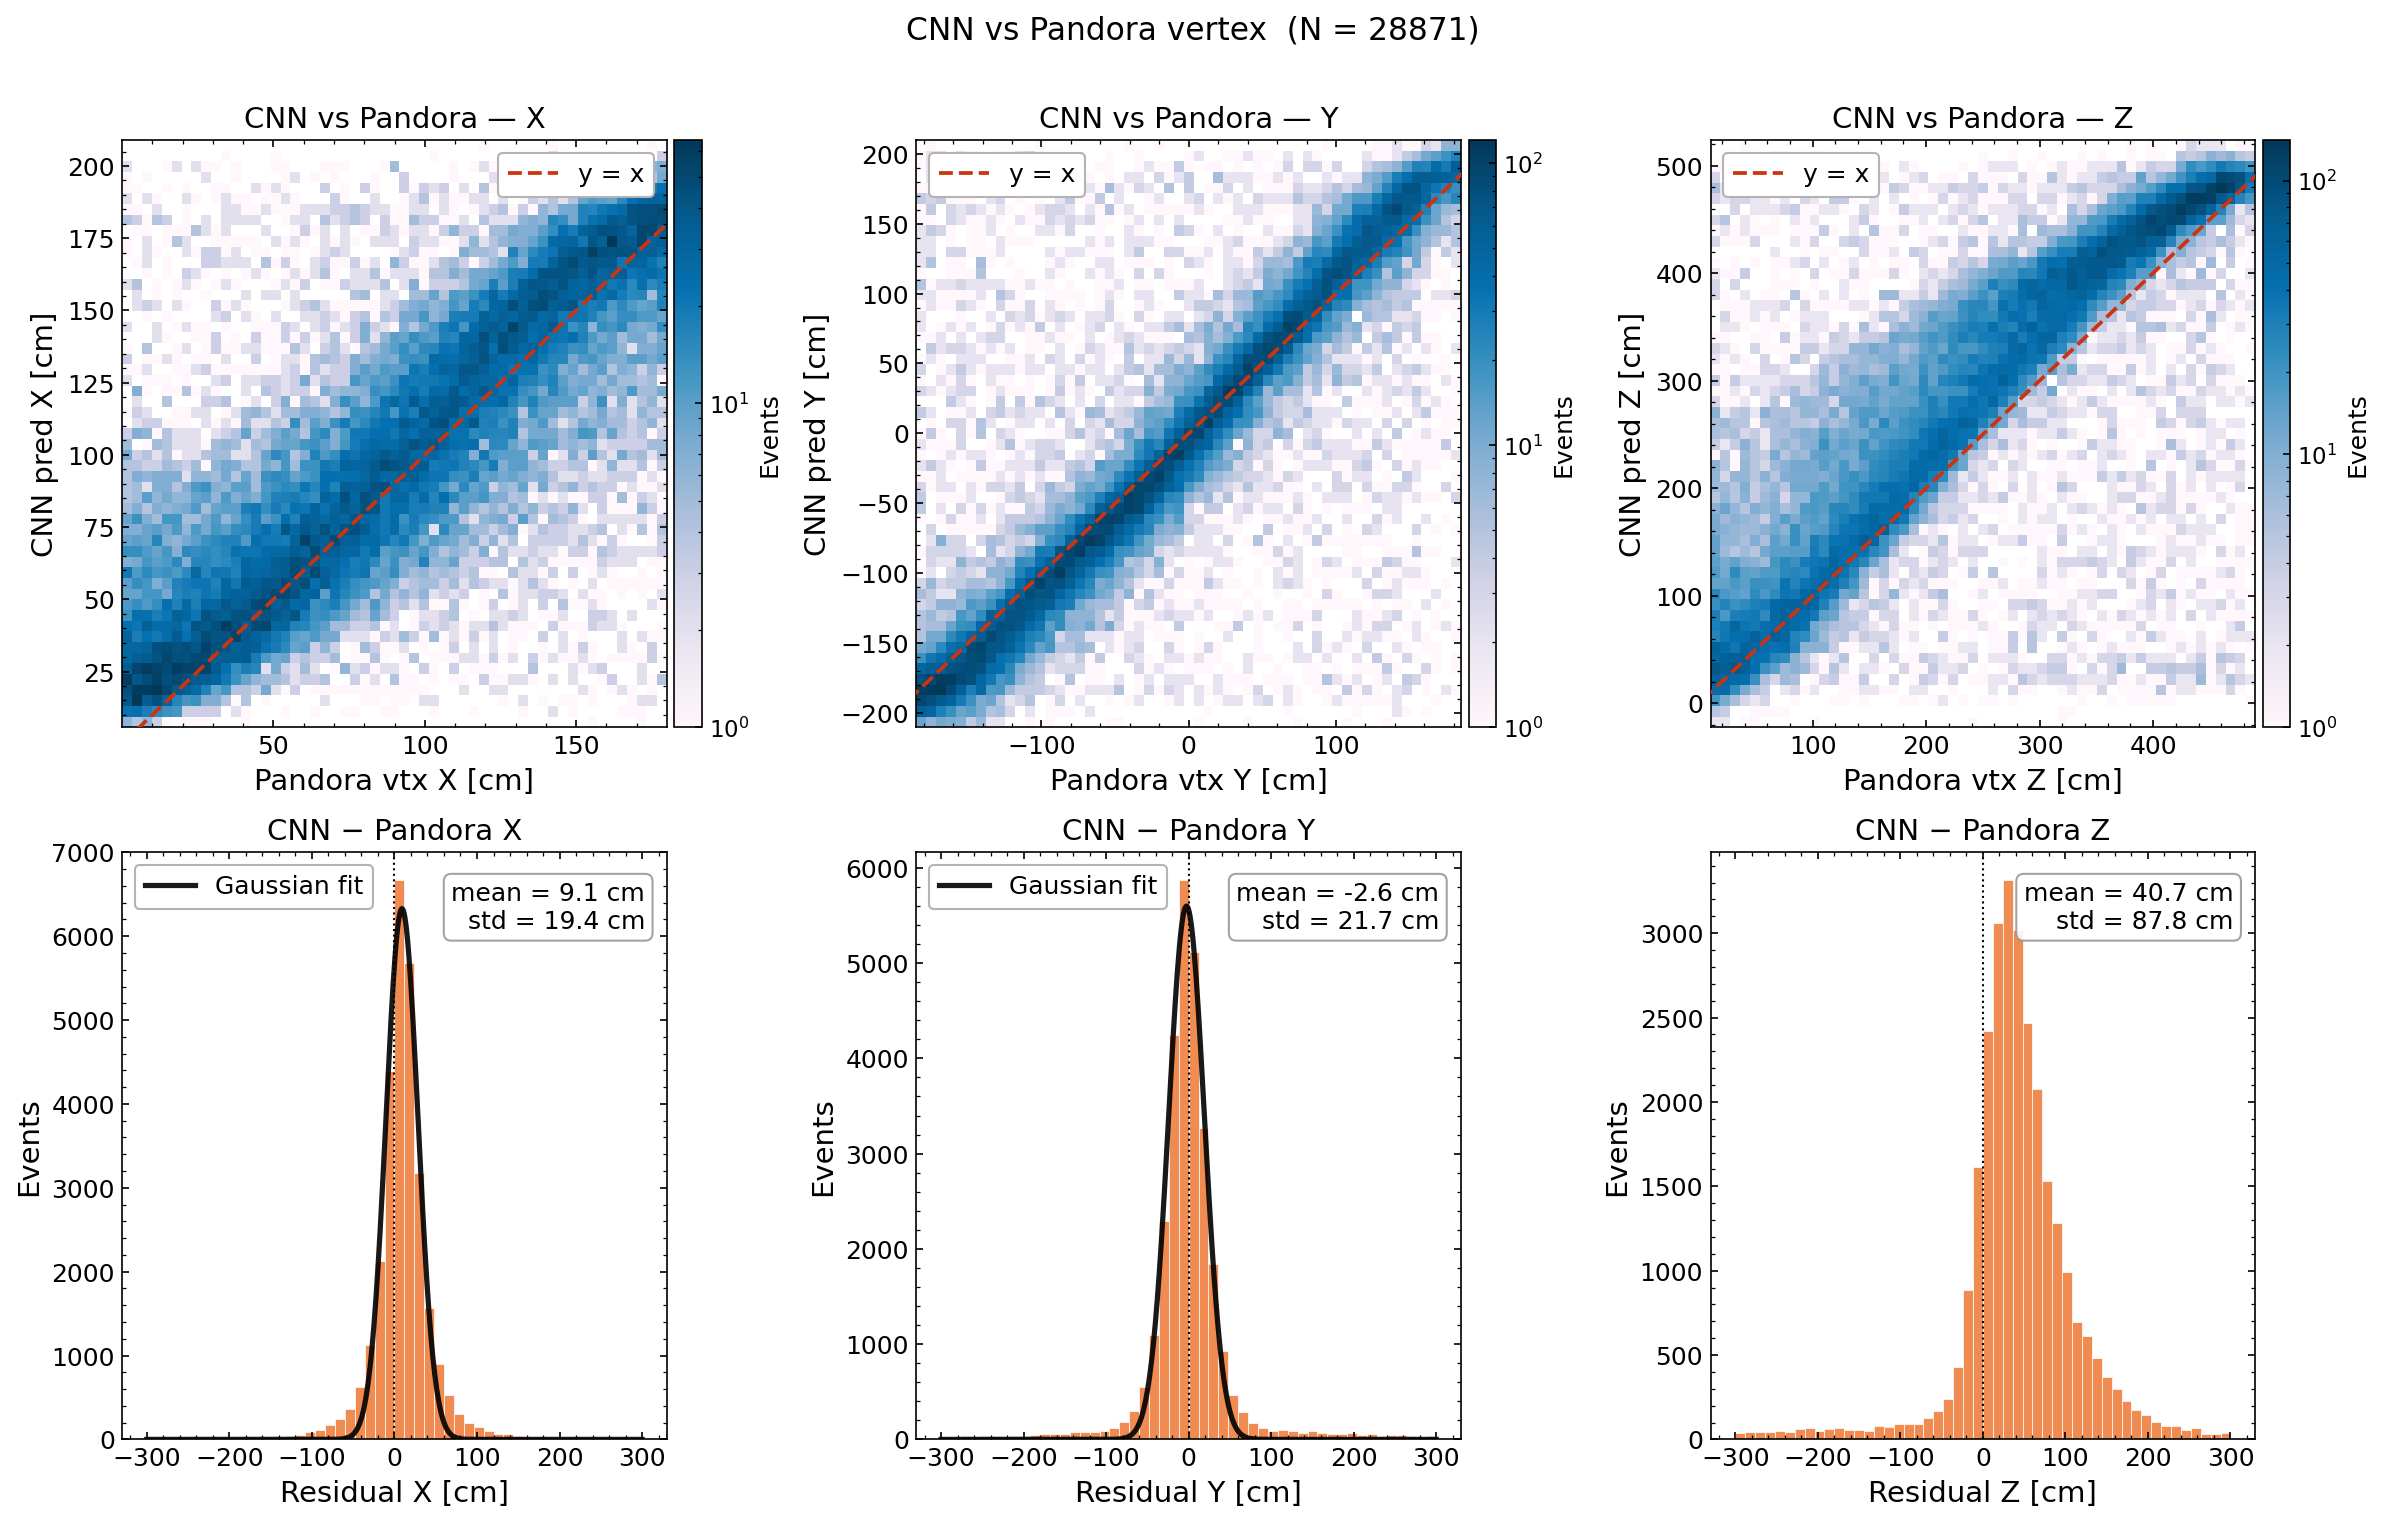

Residual 3D: mean=86.1 cm | median=59.1 cm | std=81.7 cm


In [10]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

FIT_RANGE = (-300, 300)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

scatter_cfg = [
    (np.abs(df['vtxX']), np.abs(df['pred_x']), 'Pandora vtx X [cm]', 'CNN pred X [cm]', 'CNN vs Pandora — X'),
    (df['vtxY'],         df['pred_y'],           'Pandora vtx Y [cm]', 'CNN pred Y [cm]', 'CNN vs Pandora — Y'),
    (df['vtxZ'],         df['pred_z'],           'Pandora vtx Z [cm]', 'CNN pred Z [cm]', 'CNN vs Pandora — Z'),
]
for i, (xv, yv, xl, yl, title) in enumerate(scatter_cfg):
    ax = axes[0, i]
    h = ax.hist2d(xv, yv, bins=55, cmap=CMAP_2D,
                  norm=mpl.colors.LogNorm(vmin=1), rasterized=True)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cb = plt.colorbar(h[3], cax=cax)
    cb.set_label('Events', fontsize=FONT_TICK)
    cb.ax.tick_params(labelsize=FONT_TICK - 1)
    lims = [min(xv.min(), yv.min()), max(xv.max(), yv.max())]
    ax.plot(lims, lims, '--', color=C_ALERT, lw=1.8, label='y = x', zorder=5)
    ax.set_xlabel(xl, fontsize=FONT_LABEL)
    ax.set_ylabel(yl, fontsize=FONT_LABEL)
    ax.set_title(title, fontsize=FONT_LABEL, fontweight='normal')
    ax.legend(fontsize=FONT_TICK)

res_cfg = [
    ('res_x', 'Residual X [cm]', 'CNN − Pandora X', True),
    ('res_y', 'Residual Y [cm]', 'CNN − Pandora Y', True),
    ('res_z', 'Residual Z [cm]', 'CNN − Pandora Z', False),
]
for i, (col, xl, title, do_fit) in enumerate(res_cfg):
    ax = axes[1, i]
    vals = df[col].values
    counts, bins, _ = ax.hist(vals, bins=50, range=FIT_RANGE,
                              color=C_SECONDARY, edgecolor='white',
                              linewidth=0.4, alpha=0.85)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    ax.axvline(0, color='k', lw=1.0, linestyle=':')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cax.set_visible(False)
    if do_fit:
        try:
            popt, _ = curve_fit(gaussian, bin_centers, counts,
                                p0=[counts.max(), np.median(vals), np.std(vals)], maxfev=5000)
            x_fit = np.linspace(*FIT_RANGE, 500)
            ax.plot(x_fit, gaussian(x_fit, *popt), color='k', lw=2.5, alpha=0.9,
                    label='Gaussian fit', zorder=5)
            mu, sigma = popt[1], abs(popt[2])
        except Exception:
            mu, sigma = np.mean(vals), np.std(vals)
        ax.legend(fontsize=FONT_TICK)
    else:
        mu, sigma = np.mean(vals), np.std(vals)
    ax.set_xlabel(xl, fontsize=FONT_LABEL)
    ax.set_ylabel('Events', fontsize=FONT_LABEL)
    ax.set_title(title, fontsize=FONT_LABEL, fontweight='normal')
    ax.text(0.96, 0.95, f'mean = {mu:.1f} cm\nstd = {sigma:.1f} cm',
            transform=ax.transAxes, fontsize=FONT_STAT + 1,
            va='top', ha='right', bbox=STAT_BOX)

fig.suptitle(f'CNN vs Pandora vertex  (N = {len(df)})', fontsize=FONT_LABEL + 1, y=1.01, fontweight='normal')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'CNN_vs_pandora.png'), dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

print(f"Residual 3D: mean={df['res_3d'].mean():.1f} cm | median={df['res_3d'].median():.1f} cm | std={df['res_3d'].std():.1f} cm")

## 5. CNN vs Charge Barycenter

Mismo análisis que la sección anterior pero usando el baricentro de carga de SpacePoints como referencia en lugar del vértice Pandora. Permite comparar la precisión de CNN frente a dos estimadores de posición independientes.

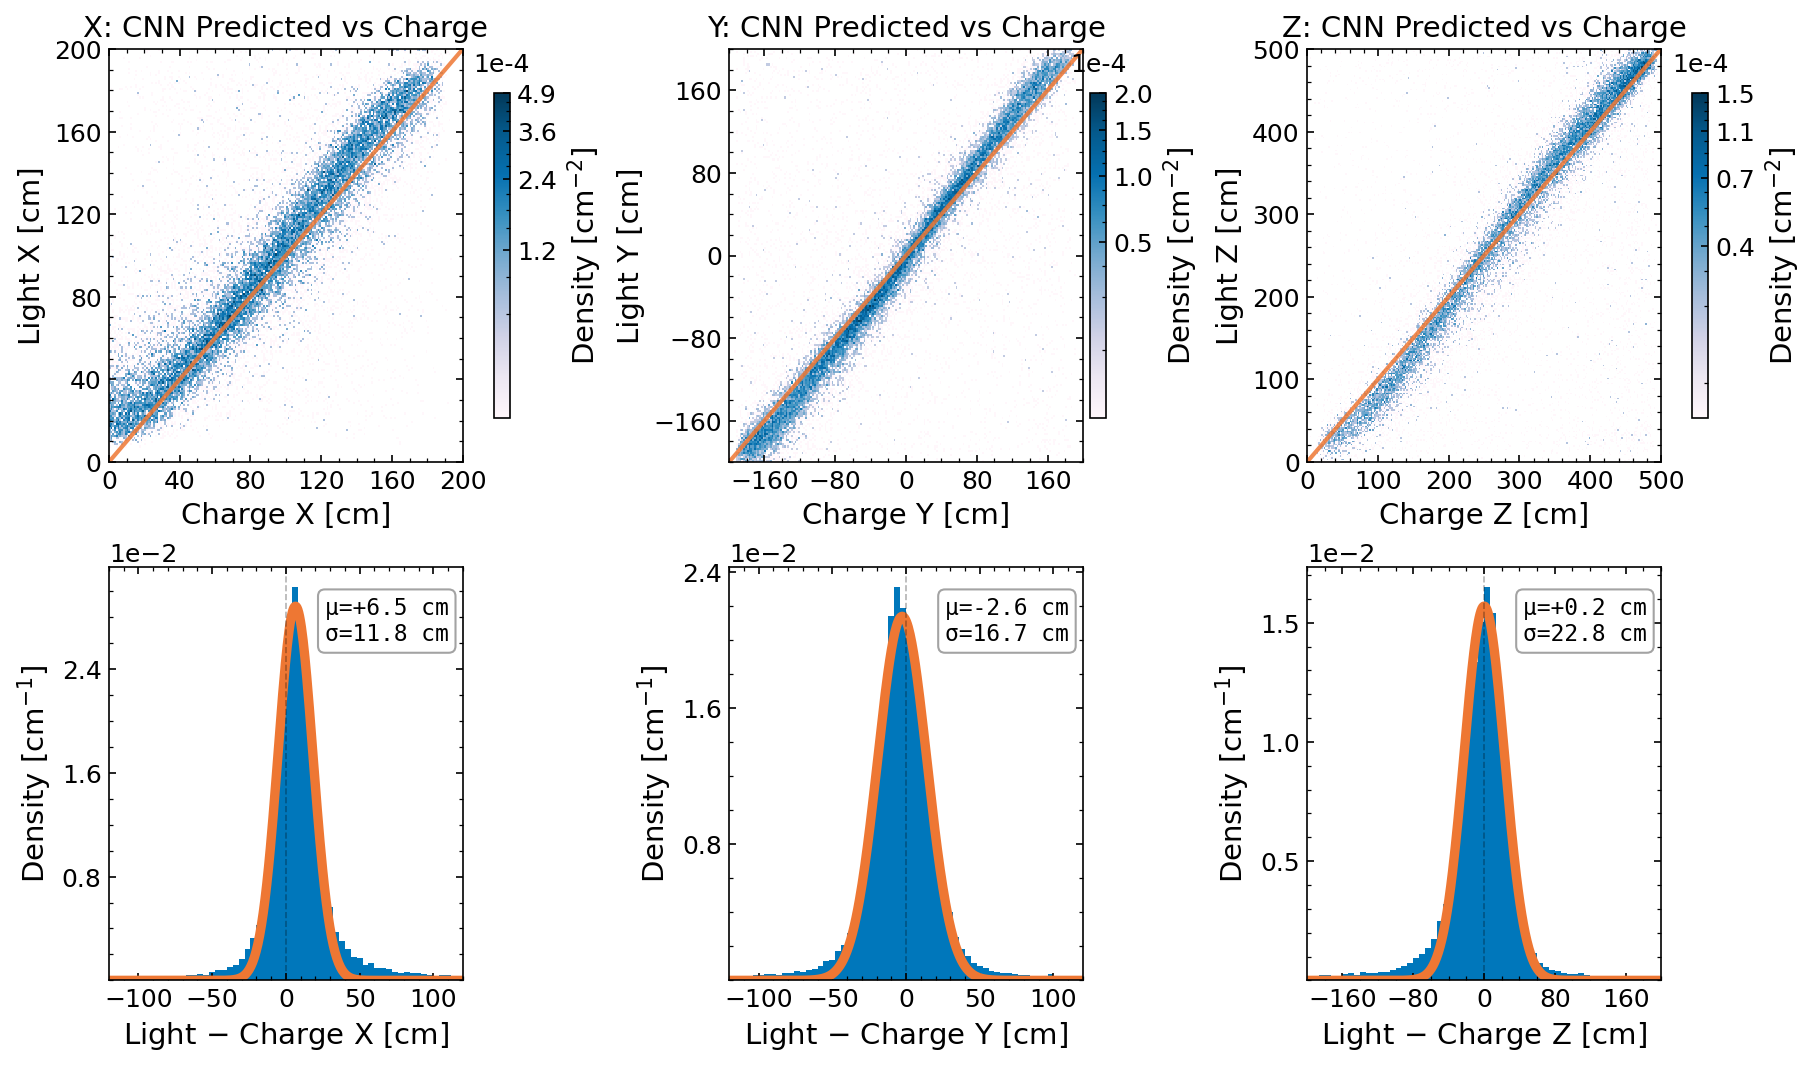

Residual 3D CNN-Bary: mean=59.6 cm | median=30.5 cm | std=83.5 cm


In [23]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.ticker import AutoMinorLocator
import math

_fl = FONT_LABEL; _ft = FONT_TICK; _fstat = FONT_STAT

def fit_pos_residuals(diff, res_range=200, nbins=200, n_sigma=2.5, n_iter=3, density=False):
    bins = np.linspace(-res_range, res_range, nbins + 1)
    cnt, edges = np.histogram(diff, bins=bins, density=density)
    cx = (edges[:-1] + edges[1:]) / 2
    peak  = cnt.max()
    mu0   = cx[cnt.argmax()]
    above = cx[cnt >= peak / 2]
    sig0  = (above[-1] - above[0]) / 2.35 if len(above) > 1 else 20.0
    popt  = [peak, mu0, sig0]
    for _ in range(n_iter):
        mu_c, sig_c = popt[1], abs(popt[2])
        lo = max(mu_c - n_sigma * sig_c, -res_range)
        hi = min(mu_c + n_sigma * sig_c,  res_range)
        mask = (cx >= lo) & (cx <= hi) & (cnt > 0)
        if mask.sum() < 5:
            break
        try:
            from scipy.optimize import curve_fit as _cf
            popt, _ = _cf(gaussian, cx[mask], cnt[mask], p0=popt,
                          bounds=([0, -res_range, 0.1], [np.inf, res_range, res_range]),
                          maxfev=10000)
        except Exception:
            break
    return popt

# ── Data ──────────────────────────────────────────────────────────────────────
df['bary_res_x']  = np.abs(df['pred_x']) - np.abs(df['spBaryX'])
df['bary_res_y']  = df['pred_y'] - df['spBaryY']
df['bary_res_z']  = df['pred_z'] - df['spBaryZ']
df['bary_res_3d'] = np.sqrt(df['bary_res_x']**2 + df['bary_res_y']**2 + df['bary_res_z']**2)

pos_names    = ['X',                           'Y',             'Z'      ]
coord_charge = [np.abs(df['spBaryX']).values,  df['spBaryY'].values, df['spBaryZ'].values]
coord_pred   = [np.abs(df['pred_x']).values,   df['pred_y'].values,  df['pred_z'].values ]
coord_limits = [(0, 200),                      (-200, 200),     (0, 500) ]
coord_bins   = [200,                            200,             250      ]
diff_cols    = ['bary_res_x',                  'bary_res_y',    'bary_res_z']
bias_zoom    = [120,                            120,             200      ]

fig, axs = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)

for i, (coord, xv, yv, limits, nbins, bz) in enumerate(
        zip(pos_names, coord_charge, coord_pred, coord_limits, coord_bins, bias_zoom)):

    diff = df[diff_cols[i]].dropna().values

    # ── Top: CNN vs Charge (2D density) ───────────────────────────────────────
    ax = axs[0, i]
    hist, xe, ye = np.histogram2d(xv, yv, bins=nbins, range=[limits, limits], density=True)
    exp  = int(math.floor(math.log10(hist.max()))) if hist.max() > 0 else 0
    hm   = np.ma.masked_where(hist <= 0, hist / 10**exp)
    im   = ax.pcolormesh(xe, ye, hm.T, cmap=CMAP_2D, shading='auto',
                         norm=mcolors.PowerNorm(gamma=0.4))
    cb   = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046, label=r'Density [cm$^{-2}$]')
    cb.ax.set_title(f'1e{exp}', fontsize=_ft, pad=10, fontweight='normal')
    cb_max = float(hm.compressed().max()) if hm.count() > 0 else 1.0
    cb.set_ticks(np.linspace(cb_max / 4, cb_max, 4))
    cb.set_ticklabels([f'{t:.1f}' for t in np.linspace(cb_max / 4, cb_max, 4)])
    ax.plot(limits, limits, color=C_SECONDARY, lw=2.0, alpha=0.85)
    ax.set_xlim(limits); ax.set_ylim(limits)
    ax.set_xlabel(f'Charge {coord} [cm]', fontsize=_fl)
    ax.set_ylabel(f'Light {coord} [cm]', fontsize=_fl)
    ax.set_title(f'{coord}: CNN Predicted vs Charge', fontsize=_fl, fontweight='normal')
    ax.tick_params(labelsize=_ft)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

    # ── Bottom: Bias histogram + Gaussian fit ──────────────────────────────────
    ax = axs[1, i]
    popt = fit_pos_residuals(diff, density=True)
    mu, sig = popt[1], abs(popt[2])
    bins_z = np.linspace(-bz, bz, 61)
    ax.hist(diff, bins=bins_z, color=C_PRIMARY, edgecolor='none', density=True)
    x_fit = np.linspace(-bz, bz, 400)
    ax.plot(x_fit, gaussian(x_fit, popt[0], mu, sig), color=C_SECONDARY, lw=4.5)
    ax.axvline(0, color='k', ls='--', alpha=0.3, lw=0.8)
    ax.set_xlabel(f'Light $-$ Charge {coord} [cm]', fontsize=_fl)
    ax.set_ylabel('Density [cm$^{-1}$]', fontsize=_fl)
    ax.set_xlim(-bz, bz)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.tick_params(labelsize=_ft)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(4, prune='lower'))
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.get_offset_text().set_fontsize(_ft)
    ax.text(0.96, 0.93, f'μ={mu:+.1f} cm\nσ={sig:.1f} cm',
            transform=ax.transAxes, fontsize=_fstat, va='top', ha='right',
            family='monospace', bbox=STAT_BOX)

fig.savefig(os.path.join(FIG_DIR, 'CNN_vs_barycenter.png'), dpi=SAVE_DPI, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'CNN_vs_barycenter.pdf'), bbox_inches='tight')
plt.show()

print(f"Residual 3D CNN-Bary: mean={df['bary_res_3d'].mean():.1f} cm | median={df['bary_res_3d'].median():.1f} cm | std={df['bary_res_3d'].std():.1f} cm")

## 6. Angle CNN 2D direction vs Charge SpacePoint PCA (YZ plane)

CNN predicts a **2D direction in YZ**: `(pred_dir_y, pred_dir_z)`.  
The charge SpacePoint PCA gives a **3D direction**: `(spPCAx, spPCAy, spPCAz)` — charge-weighted.  
We project the PCA onto YZ and compute the angle. Since PCA direction is ambiguous (±), we take `min(θ, 180°−θ)`.

Proyecta el PCA de carga al plano YZ, normaliza y calcula el ángulo con la dirección CNN (con ambigüedad de signo resuelta tomando `min(θ, 180°−θ)`). Muestra la distribución del ángulo, su correlación con nSpacePoints/NuScore, y su relación con el residuo 3D.

Valid rows for angle comparison: 28871 / 28871


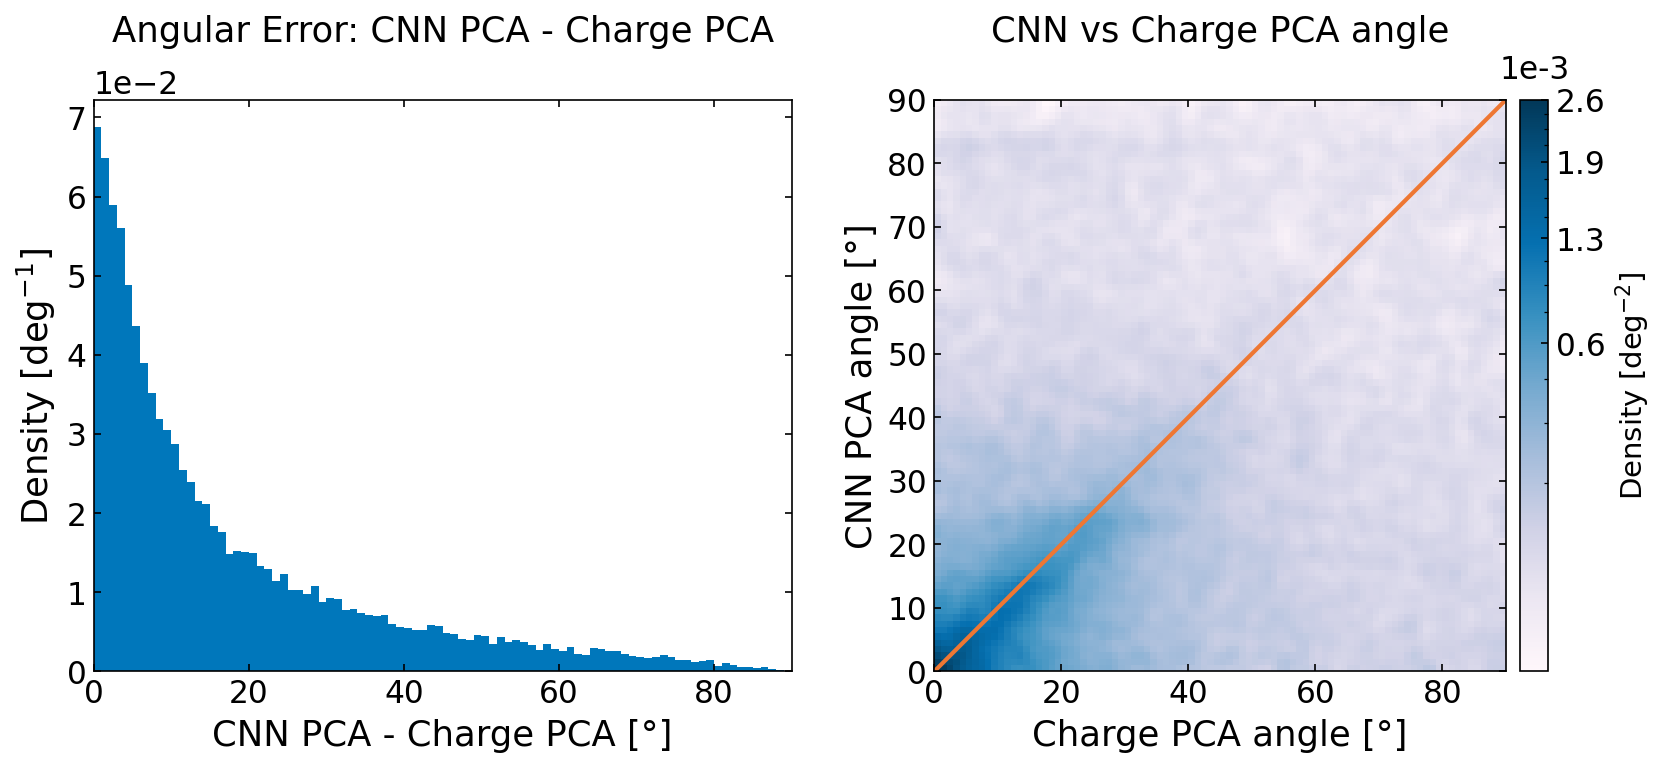

Charge PCA angle — mean: 26.8°  std: 22.4°
CNN angle     — mean: 22.3°  std: 20.2°
PCA − CNN   — mean: 17.7°  median: 10.8°  std: 18.4°


In [12]:
import math
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter
import matplotlib.ticker as mticker

_fl = 17; _ft = 15; _fs = 15

# ── Filter valid rows ─────────────────────────────────────────────────────
df_dir = df[
    (df['pred_dir_y'] > PLACEHOLDER) &
    (df['spPCAy'] > PLACEHOLDER) &
    (df['spPCAz'] > PLACEHOLDER)
].copy()

print(f"Valid rows for angle comparison: {len(df_dir)} / {len(df)}")

mag_rn = np.sqrt(df_dir['pred_dir_y']**2 + df_dir['pred_dir_z']**2)
df_dir['CNN_angle'] = np.degrees(
    np.arccos(np.clip(df_dir['pred_dir_z'].abs() / mag_rn, -1, 1))
)

pca_yz_norm = np.sqrt(df_dir['spPCAy']**2 + df_dir['spPCAz']**2)
pca_yz_norm = pca_yz_norm.where(pca_yz_norm > 0, 1.0)
df_dir['pca_angle'] = np.degrees(
    np.arccos(np.clip(df_dir['spPCAz'].abs() / pca_yz_norm, -1, 1))
)

angle_pca = df_dir['pca_angle'].values
angle_CNN = df_dir['CNN_angle'].values
angle_err = np.abs(angle_pca - angle_CNN)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)

# ── Left: |Charge PCA − CNN| error ───────────────────────────────────────────
ax = axes[0]
ax.hist(angle_err, bins=90, range=(0, 90),
        color=C_PRIMARY, edgecolor='none', density=True)
ax.set_xlabel('CNN PCA - Charge PCA [°]', fontsize=_fl)
ax.set_ylabel('Density [deg$^{-1}$]', fontsize=_fl)
ax.set_title('Angular Error: CNN PCA - Charge PCA',
             fontsize=_fl, fontweight='normal', y=1.08)

ax.set_xlim(0, 90)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.tick_params(labelsize=_ft)
ax.yaxis.get_offset_text().set_fontsize(_ft)
ax.minorticks_off()

# ── Right: 2D scatter Charge PCA vs CNN ─────────────────────────────────
ax = axes[1]
h, xe, ye = np.histogram2d(angle_pca, angle_CNN, bins=90,
                            range=[(0, 90), (0, 90)], density=True)

h_smooth = gaussian_filter(h, sigma=1.0)
exp_d = int(math.floor(math.log10(h_smooth.max()))) if h_smooth.max() > 0 else 0
hm = np.ma.masked_where(h_smooth <= 0, h_smooth / 10**exp_d)

im = ax.pcolormesh(xe, ye, hm.T, cmap=CMAP_2D, shading='auto',
                   norm=mcolors.PowerNorm(gamma=0.4))

cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046,
                  label=r'Density [deg$^{-2}$]')
cb.ax.set_title(f'1e{exp_d}', fontsize=_ft, pad=10, fontweight='normal')
cb.ax.tick_params(labelsize=_ft)

cb_max_d = float(hm.compressed().max()) if hm.count() > 0 else 1.0
cb_ticks_d = np.linspace(cb_max_d / 4, cb_max_d, 4)
cb.set_ticks(cb_ticks_d)
cb.set_ticklabels([f'{t:.1f}' for t in cb_ticks_d])

ax.plot([0, 90], [0, 90], color=C_SECONDARY, lw=2.0)
ax.set_xlim(0, 90); ax.set_ylim(0, 90)

ax.set_xlabel('Charge PCA angle [°]', fontsize=_fl)
ax.set_ylabel('CNN PCA angle [°]', fontsize=_fl)
ax.set_title('CNN vs Charge PCA angle',
             fontsize=_fl, fontweight='normal', y=1.08)

ax.set_aspect('equal')
ax.tick_params(labelsize=_ft)
ax.minorticks_off()

fig.savefig(os.path.join(FIG_DIR, 'angle_comparison.png'),
            dpi=SAVE_DPI, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'angle_comparison.pdf'),
            bbox_inches='tight')

plt.show()

print(f"Charge PCA angle — mean: {angle_pca.mean():.1f}°  std: {angle_pca.std():.1f}°")
print(f"CNN angle     — mean: {angle_CNN.mean():.1f}°  std: {angle_CNN.std():.1f}°")
print(f"PCA − CNN   — mean: {angle_err.mean():.1f}°  median: {np.median(angle_err):.1f}°  std: {angle_err.std():.1f}°")